In [1]:
!ls -lh results2

total 1326688
drwxr-xr-x  1820 egozi  staff    57K Dec 28 13:30 images
-rwxr-xr-x     1 egozi  staff    56M Dec 28 13:30 test.h5
-rwxr-xr-x     1 egozi  staff   592M Dec 28 13:19 train.h5


In [1]:
import h5py
import numpy as np
import matplotlib.pylab as plt
%matplotlib widget

In [2]:
test_fn = "results2/test_withLabels.h5"
train_fn = "results2/train.h5"
train_fn = "/home/amir/source/MySynthText/results/SynthText_test.h5"

test_fn_noLabels = "results2/test.h5"

In [3]:
db = h5py.File(train_fn, 'r') 

In [4]:
keys = list(db['data'].keys())

In [5]:
len(keys)

2

In [6]:
im = db['data'][keys[0]][:]

In [7]:
keys

['building_34.jpg_0', 'cows_114.jpg_0']

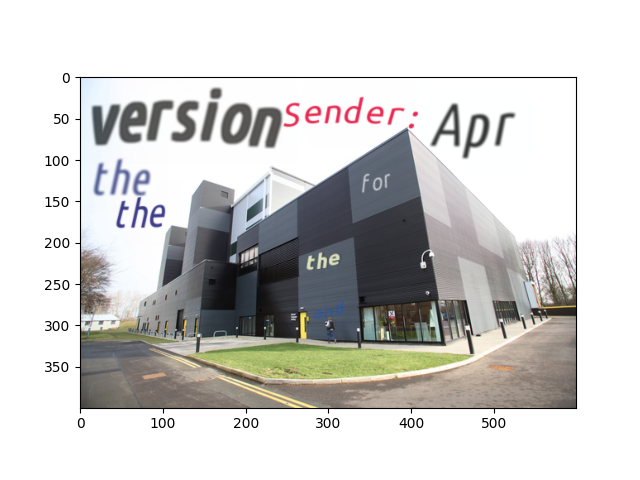

In [8]:
plt.figure()
plt.imshow(im)

In [9]:
# Read fonts.txt into a list
with open('data/fonts.txt', 'r') as f:
  font_name = [line.strip() for line in f if line.strip()]

print(font_name)


['Ubuntu', 'Ubuntu Condensed', 'Ubuntu Mono']


In [10]:
np.array(font_name)

array(['Ubuntu', 'Ubuntu Condensed', 'Ubuntu Mono'], dtype='<U16')

In [ ]:
# np.unique(font_list).tolist()
font_name = ['Skylark',
             'Sweet Puppy',
             'Ubuntu Mono',
             'VertigoFLF',
             'Wanted M54',
             'always forever',
             'Flower Rose Brush']
font_name = ['Ubuntu',
            'Ubuntu Condensed',          
            'Ubuntu Mono' ]

In [11]:
color_list = ["r", "b", "y", "k", "m", "w", "g"]

In [14]:
font_list

array(['Ubuntu Condensed', 'Ubuntu Condensed', 'Ubuntu Condensed',
       'Ubuntu Condensed', 'Ubuntu Condensed', 'Ubuntu Condensed',
       'Ubuntu Condensed', 'Ubuntu Condensed', 'Ubuntu Condensed',
       'Ubuntu Condensed', 'Ubuntu', 'Ubuntu', 'Ubuntu',
       'Ubuntu Condensed', 'Ubuntu Condensed', 'Ubuntu Condensed',
       'Ubuntu Mono', 'Ubuntu Mono', 'Ubuntu Mono', 'Ubuntu Condensed',
       'Ubuntu Condensed', 'Ubuntu Condensed', 'Ubuntu Condensed',
       'Ubuntu Condensed', 'Ubuntu Condensed', 'Ubuntu Mono',
       'Ubuntu Mono', 'Ubuntu Mono', 'Ubuntu Mono', 'Ubuntu Mono',
       'Ubuntu Mono', 'Ubuntu Mono'], dtype=object)

['version' 'for' 'the' 'the' 'and' 'Apr' 'the' 'Sender:']


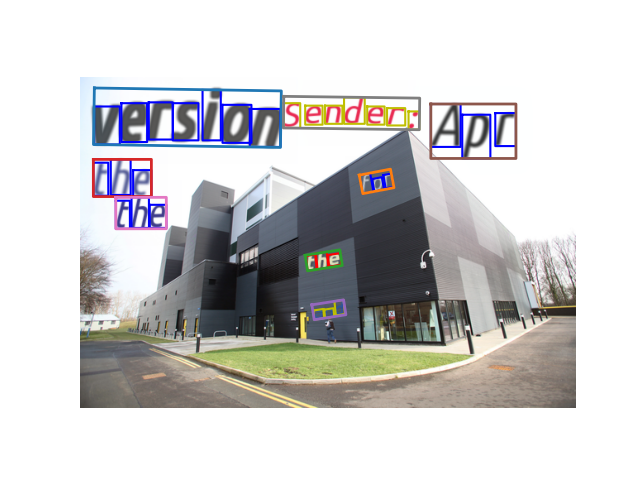

In [13]:
db = h5py.File(train_fn, 'r') 

k = 0
im_data = db["data"][keys[k]]

im = im_data[:]
font_list = im_data.attrs['font']
char_bb = im_data.attrs['charBB']
word_bb = im_data.attrs['wordBB']
text = im_data.attrs['txt']

nC = char_bb.shape[-1]

plt.figure()
plt.imshow(im)
for b_inx in range(nC):
    c_inx = font_name.index(font_list[b_inx])
    color = color_list[c_inx]
    
    bb = char_bb[:,:,b_inx]
    x = np.append(bb[0,:], bb[0,0])
    y = np.append(bb[1,:], bb[1,0])
    plt.plot(x, y, color)

# plot the word BB
nW = word_bb.shape[-1]
for w_inx in range(nW):
    bb = word_bb[:,:,w_inx]
    x = np.append(bb[0,:], bb[0,0])
    y = np.append(bb[1,:], bb[1,0])
    plt.plot(x, y, lw=2)   

plt.axis('off')
print(text)

In [31]:
k = keys[0]
print(db['data'][k].attrs['charBB'].shape)
print(db['data'][k].attrs['font'].shape)
print(db['data'][k].attrs['wordBB'].shape)
print(db['data'][k].attrs['txt'])

(2, 4, 34)
(34,)
(2, 4, 7)
[b'for?' b'the' b'CPUs' b'The' b'Willmore' b'Mangled' b'will,']


In [32]:
len(''.join([s.decode('utf-8') for s in db['data'][k].attrs['txt'].tolist()]))

34

In [33]:
''.join(str(db['data'][k].attrs['txt'].tolist()))

"[b'for?', b'the', b'CPUs', b'The', b'Willmore', b'Mangled', b'will,']"

In [16]:
train_file = 'results/train.h5'
test_with_labels = 'results2/test.h5'
test_no_labels = 'results2/test.h5'

In [17]:
train_db = h5py.File(train_file, 'w')
test_w_db = h5py.File(test_with_labels, 'w')
test_n_db = h5py.File(test_no_labels, 'w')

In [18]:
train_db.create_group('/data')
test_w_db.create_group('/data')
test_n_db.create_group('/data')

<HDF5 group "/data" (0 members)>

In [19]:
for inx, k in enumerate(keys):
    print(inx, '/', len(keys))
    im = db['data'][k][:]
    if inx < 500:
        test_w_db['data'].create_dataset(k,data=im)
        test_w_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
        test_w_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
        test_w_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
        test_w_db['data'][k].attrs['font'] = db['data'][k].attrs['font']

        test_n_db['data'].create_dataset(k,data=im)
        test_n_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
        test_n_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
        test_n_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
#         test_n_db['data'][k].attrs['font'] = db['data'][k].attrs['font']

    else:
        train_db['data'].create_dataset(k,data=im)
        train_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
        train_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
        train_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
        train_db['data'][k].attrs['font'] = db['data'][k].attrs['font']

0 / 1664
1 / 1664
2 / 1664
3 / 1664
4 / 1664
5 / 1664
6 / 1664
7 / 1664
8 / 1664
9 / 1664
10 / 1664
11 / 1664
12 / 1664
13 / 1664
14 / 1664
15 / 1664
16 / 1664
17 / 1664
18 / 1664
19 / 1664
20 / 1664
21 / 1664
22 / 1664
23 / 1664
24 / 1664
25 / 1664
26 / 1664
27 / 1664
28 / 1664
29 / 1664
30 / 1664
31 / 1664
32 / 1664
33 / 1664
34 / 1664
35 / 1664
36 / 1664
37 / 1664
38 / 1664
39 / 1664
40 / 1664
41 / 1664
42 / 1664
43 / 1664
44 / 1664
45 / 1664
46 / 1664
47 / 1664
48 / 1664
49 / 1664
50 / 1664
51 / 1664
52 / 1664
53 / 1664
54 / 1664
55 / 1664
56 / 1664
57 / 1664
58 / 1664
59 / 1664
60 / 1664
61 / 1664
62 / 1664
63 / 1664
64 / 1664
65 / 1664
66 / 1664
67 / 1664
68 / 1664
69 / 1664
70 / 1664
71 / 1664
72 / 1664
73 / 1664
74 / 1664
75 / 1664
76 / 1664
77 / 1664
78 / 1664
79 / 1664
80 / 1664
81 / 1664
82 / 1664
83 / 1664
84 / 1664
85 / 1664
86 / 1664
87 / 1664
88 / 1664
89 / 1664
90 / 1664
91 / 1664
92 / 1664
93 / 1664
94 / 1664
95 / 1664
96 / 1664
97 / 1664
98 / 1664
99 / 1664
100 / 1664

755 / 1664
756 / 1664
757 / 1664
758 / 1664
759 / 1664
760 / 1664
761 / 1664
762 / 1664
763 / 1664
764 / 1664
765 / 1664
766 / 1664
767 / 1664
768 / 1664
769 / 1664
770 / 1664
771 / 1664
772 / 1664
773 / 1664
774 / 1664
775 / 1664
776 / 1664
777 / 1664
778 / 1664
779 / 1664
780 / 1664
781 / 1664
782 / 1664
783 / 1664
784 / 1664
785 / 1664
786 / 1664
787 / 1664
788 / 1664
789 / 1664
790 / 1664
791 / 1664
792 / 1664
793 / 1664
794 / 1664
795 / 1664
796 / 1664
797 / 1664
798 / 1664
799 / 1664
800 / 1664
801 / 1664
802 / 1664
803 / 1664
804 / 1664
805 / 1664
806 / 1664
807 / 1664
808 / 1664
809 / 1664
810 / 1664
811 / 1664
812 / 1664
813 / 1664
814 / 1664
815 / 1664
816 / 1664
817 / 1664
818 / 1664
819 / 1664
820 / 1664
821 / 1664
822 / 1664
823 / 1664
824 / 1664
825 / 1664
826 / 1664
827 / 1664
828 / 1664
829 / 1664
830 / 1664
831 / 1664
832 / 1664
833 / 1664
834 / 1664
835 / 1664
836 / 1664
837 / 1664
838 / 1664
839 / 1664
840 / 1664
841 / 1664
842 / 1664
843 / 1664
844 / 1664
845 / 1664

1485 / 1664
1486 / 1664
1487 / 1664
1488 / 1664
1489 / 1664
1490 / 1664
1491 / 1664
1492 / 1664
1493 / 1664
1494 / 1664
1495 / 1664
1496 / 1664
1497 / 1664
1498 / 1664
1499 / 1664
1500 / 1664
1501 / 1664
1502 / 1664
1503 / 1664
1504 / 1664
1505 / 1664
1506 / 1664
1507 / 1664
1508 / 1664
1509 / 1664
1510 / 1664
1511 / 1664
1512 / 1664
1513 / 1664
1514 / 1664
1515 / 1664
1516 / 1664
1517 / 1664
1518 / 1664
1519 / 1664
1520 / 1664
1521 / 1664
1522 / 1664
1523 / 1664
1524 / 1664
1525 / 1664
1526 / 1664
1527 / 1664
1528 / 1664
1529 / 1664
1530 / 1664
1531 / 1664
1532 / 1664
1533 / 1664
1534 / 1664
1535 / 1664
1536 / 1664
1537 / 1664
1538 / 1664
1539 / 1664
1540 / 1664
1541 / 1664
1542 / 1664
1543 / 1664
1544 / 1664
1545 / 1664
1546 / 1664
1547 / 1664
1548 / 1664
1549 / 1664
1550 / 1664
1551 / 1664
1552 / 1664
1553 / 1664
1554 / 1664
1555 / 1664
1556 / 1664
1557 / 1664
1558 / 1664
1559 / 1664
1560 / 1664
1561 / 1664
1562 / 1664
1563 / 1664
1564 / 1664
1565 / 1664
1566 / 1664
1567 / 1664
1568

In [20]:
train_db.close()
test_w_db.close()
test_n_db.close()

In [39]:
test_with_labels = "results2/test_withLabels.h5"
train_fn = "results2/train.h5"

test_no_labels = "results2/test.h5"

test_w_db = h5py.File(test_with_labels, 'r')
test_n_db = h5py.File(test_no_labels, 'w')

In [40]:
test_n_db.create_group('/data')

keys = list(test_w_db['data'].keys())

In [42]:
for inx, k in enumerate(keys):
    print(inx, '/', len(keys))
    im = test_w_db['data'][k][:]

    test_n_db['data'].create_dataset(k, data=im)
    test_n_db['data'][k].attrs['charBB'] = test_w_db['data'][k].attrs['charBB']
    test_n_db['data'][k].attrs['wordBB'] = test_w_db['data'][k].attrs['wordBB']        
    test_n_db['data'][k].attrs['txt'] = test_w_db['data'][k].attrs['txt']
#         test_n_db['data'][k].attrs['font'] = db['data'][k].attrs['font']

test_n_db.close()

0 / 80
1 / 80
2 / 80
3 / 80
4 / 80
5 / 80
6 / 80
7 / 80
8 / 80
9 / 80
10 / 80
11 / 80
12 / 80
13 / 80
14 / 80
15 / 80
16 / 80
17 / 80
18 / 80
19 / 80
20 / 80
21 / 80
22 / 80
23 / 80
24 / 80
25 / 80
26 / 80
27 / 80
28 / 80
29 / 80
30 / 80
31 / 80
32 / 80
33 / 80
34 / 80
35 / 80
36 / 80
37 / 80
38 / 80
39 / 80
40 / 80
41 / 80
42 / 80
43 / 80
44 / 80
45 / 80
46 / 80
47 / 80
48 / 80
49 / 80
50 / 80
51 / 80
52 / 80
53 / 80
54 / 80
55 / 80
56 / 80
57 / 80
58 / 80
59 / 80
60 / 80
61 / 80
62 / 80
63 / 80
64 / 80
65 / 80
66 / 80
67 / 80
68 / 80
69 / 80
70 / 80
71 / 80
72 / 80
73 / 80
74 / 80
75 / 80
76 / 80
77 / 80
78 / 80
79 / 80


(73, 246, 3)
(63, 422, 3)
(81, 503, 3)
(45, 356, 3)
(66, 112, 3)
(51, 288, 3)
(102, 463, 3)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1000 and the array at index 2 has size 999

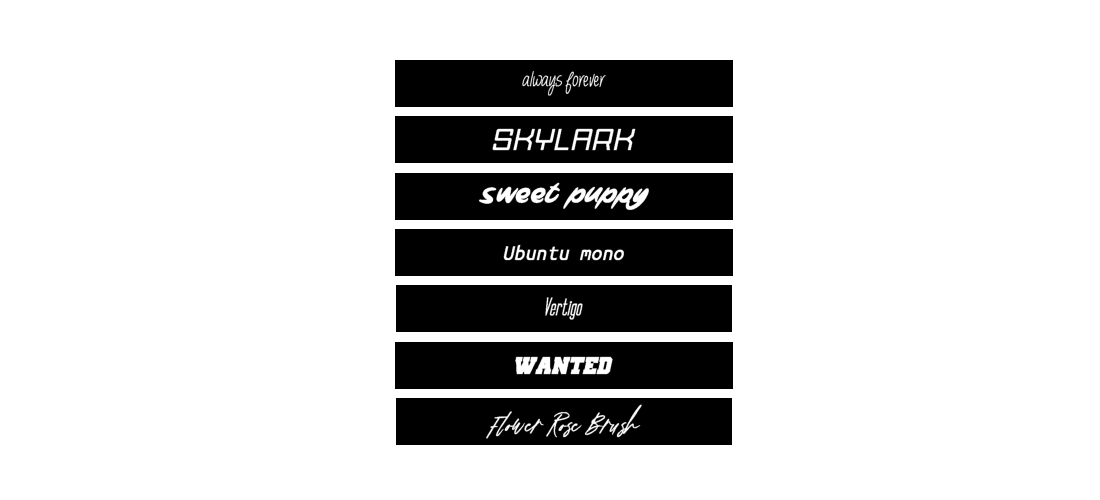

In [88]:
# RENDER_TEXT = "abcdefghijklmnopqrstuvwxyz ABCDEFGHIJKLMNOPQRSTUVWXYZ 0123456789`-=~!@#$%^&*()_+[]\\{}|;':\",./<>?"
RENDER_TEXT = "a b c d e f g h i A B C D E F G H I 0 1 2 3 4 5 6 7 8 9"

RENDER_TEXT = ["always forever", "Skylark", "Sweet puppy", "Ubuntu mono", "Vertigo", "Wanted", "Flower Rose Brush"]
from pygame.freetype import Font
from pygame import Color


font_name = [b'Skylark',
             b'Sweet Puppy',
             b'Ubuntu Mono',
             b'VertigoFLF',
             b'Wanted M54',
             b'always  forever',
             b'Flower Rose Brush']

files = ["data/fonts/always-forever/always_forever.ttf",
         "data/fonts/skylark/Skylark.ttf",
         "data/fonts/SweetPuppy/SweetPuppy.ttf",
         "data/fonts/ubuntumono/UbuntuMono-Regular.ttf",
         "data/fonts/vertigo/VertigoFLF.ttf",
         "data/fonts/wanted/WantedM54.ttf", 
         "data/fonts/Flower-Rose/FlowerRoseBrush.ttf"]

_, axes = plt.subplots(7,1, figsize=(11,5))

size = (140, 2500)
size = (140, 1000)

im_list = []
for inx, file in enumerate(files):

    font = Font(file, size=64)
    font.strong = True
    font.oblique = True
    font.antialiased = True
    font.origin = True
    font.strength = 0.01
    surface, _ = font.render(
        RENDER_TEXT[inx],
        fgcolor=Color(255, 255, 255, 255),
        bgcolor=Color(0, 0, 0, 0))
    img = pygame.surfarray.array3d(surface)
    img = np.transpose(img, [1, 0, 2])
    print(img.shape)

    # pad image
    h = (size[0] - img.shape[0]) // 2
    w = (size[1] - img.shape[1]) // 2
    img = np.pad(img, ((h,h), (w,w), (0,0)))

    axes[inx].imshow(img)
    axes[inx].set_axis_off()

    im_list.append(img)

im_list = [m[:140, :2499, :] for m in im_list]
im = np.concatenate(im_list, axis=0)



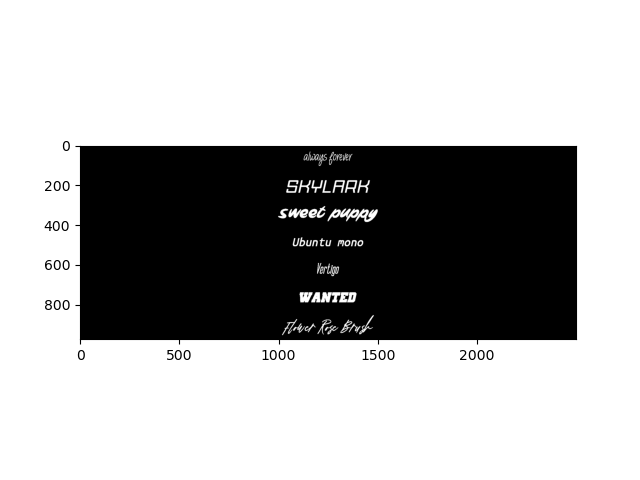

In [86]:
plt.figure()
plt.imshow(im)

In [96]:
import re

# fix encoding of font names
fn = "results2/test_withLabels.h5"
fix = "results2/test_with_labels.h5"
# train_fn = "results2/train.h5"
# train_fix = "results/train.h5"


db = h5py.File(fn, 'r')
fix_db = h5py.File(fix, 'w')

fix_db.create_group('/data')

keys = list(db['data'].keys())

for inx, k in enumerate(keys):
    print(inx, '/', len(keys))
    im = db['data'][k][:]

    fix_db['data'].create_dataset(k, data=im)
    fix_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
    fix_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
    fix_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
    fonts = db['data'][k].attrs['font']
    fix_db['data'][k].attrs['font'] = [re.sub(' +', ' ',f.decode("UTF-8")) for f in fonts]
    

fix_db.close()

0 / 80
1 / 80
2 / 80
3 / 80
4 / 80
5 / 80
6 / 80
7 / 80
8 / 80
9 / 80
10 / 80
11 / 80
12 / 80
13 / 80
14 / 80
15 / 80
16 / 80
17 / 80
18 / 80
19 / 80
20 / 80
21 / 80
22 / 80
23 / 80
24 / 80
25 / 80
26 / 80
27 / 80
28 / 80
29 / 80
30 / 80
31 / 80
32 / 80
33 / 80
34 / 80
35 / 80
36 / 80
37 / 80
38 / 80
39 / 80
40 / 80
41 / 80
42 / 80
43 / 80
44 / 80
45 / 80
46 / 80
47 / 80
48 / 80
49 / 80
50 / 80
51 / 80
52 / 80
53 / 80
54 / 80
55 / 80
56 / 80
57 / 80
58 / 80
59 / 80
60 / 80
61 / 80
62 / 80
63 / 80
64 / 80
65 / 80
66 / 80
67 / 80
68 / 80
69 / 80
70 / 80
71 / 80
72 / 80
73 / 80
74 / 80
75 / 80
76 / 80
77 / 80
78 / 80
79 / 80


# sample submission file

In [95]:

fix_db.close()

In [97]:
train_fn = "results2/train.h5"

db = h5py.File(train_fn, 'r')
keys = list(db['data'].keys())
len(keys)

829